# Off-Target Complex Generation Analysis

This notebook performs:
1. **Part 1 (After Vina):** ProLIF interaction fingerprints, visualization, pose selection
2. **Part 2 (After FastRelax):** PyRosetta QC, H-bonds, contacts, final scoring

Run Part 1 after `dataprep/off/vina_post.py`, then Part 2 after FastRelax completion.

In [1]:
# Imports
import os
import glob
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from Bio.PDB import PDBParser, Superimposer

# ProLIF for interaction fingerprints
import prolif as plf
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# PyRosetta (for Part 2)
try:
    import pyrosetta
    from pyrosetta import rosetta
    PYROSETTA_AVAILABLE = True
except ImportError:
    print("PyRosetta not available. Part 2 (QC after relaxation) will be limited.")
    PYROSETTA_AVAILABLE = False

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports complete")

/home/yunmin/opt/miniconda3/envs/ligandmpnn_env/lib/python3.11/site-packages/prolif/datafiles.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/yunmin/opt/miniconda3/envs/ligandmpnn_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yunmin/opt/miniconda3/envs/ligandmpnn_env/lib/python3.11/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=Deprec

✓ Imports complete


---
## Configuration & Setup

In [2]:
# Load configuration
BASE_DIR = Path("/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/runs")

COMPLEX_DIRS = dict()
for i in range(10000):
    if list(BASE_DIR.glob(f'complex_{i:04d}_off*')):
        COMPLEX_DIRS[i] = sorted(list(BASE_DIR.glob(f'complex_{i:04d}_off*')))
print(f"Found complex directories: {len(COMPLEX_DIRS)}")

CONFIG_DIR = Path("/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs")
CONFIG_FILES = dict()
for run_id, dirs in COMPLEX_DIRS.items():
    # print(f"Run ID: {run_id}")
    for j in range(len(dirs)):
        if run_id not in CONFIG_FILES:
            CONFIG_FILES[run_id] = []
        CONFIG_FILES[run_id].append(Path(str(CONFIG_DIR) + f"/configs_{j+1:02d}/" + os.path.basename(dirs[j]) + ".yaml"))
print(f"Configuration files: {CONFIG_FILES}")


Found complex directories: 1579
Configuration files: {81: [PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_01/complex_0081_off01.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_02/complex_0081_off02.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_03/complex_0081_off03.yaml')], 82: [PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_01/complex_0082_off01.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_02/complex_0082_off02.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_03/complex_0082_off03.yaml')], 83: [PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_01/complex_0083_off01.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_02/complex_0083_off02.yaml'), PosixPath('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_03/complex_0083_off03.yaml')], 84: [PosixPath('/sc

In [ ]:
SAMPLE_RUN_ID = list(COMPLEX_DIRS.keys())[0] # complex_0000_off_*
CONFIG_FILE = CONFIG_FILES[SAMPLE_RUN_ID][2] # config[01-03]
print(f"Using configuration file: {CONFIG_FILE}")

with open(CONFIG_FILE, 'r') as f:
    config = yaml.safe_load(f)

output_dir = Path(config['output_dir'])
dirs = {
    'prepared': output_dir / 'prepared',
    'docking': output_dir / 'docking',
    'filtered': output_dir / 'filtered',
    'relaxed': output_dir / 'relaxed',
    'final': output_dir / 'final',
    'logs': output_dir / 'logs',
}

print(f"Output directory: {output_dir}")
print(f"Configuration loaded from: {CONFIG_FILE}")

Using configuration file: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_03/complex_0081_off03.yaml
Output directory: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/runs/complex_0081_off03
Configuration loaded from: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/configs_03/complex_0081_off03.yaml


---
# PART 1: Post-Vina Analysis
Run this section after `vina_postprocess.py` completes

## 1.1 Load Filtered Poses

In [4]:
# Load filtered poses
filtered_csv = dirs['filtered'] / 'poses_filtered.csv'
df = pd.read_csv(filtered_csv)

print(f"Loaded {len(df)} filtered poses")
print(f"\nScore range: {df['vina_score'].min():.2f} to {df['vina_score'].max():.2f} kcal/mol")
print(f"RMSD range: {df['ligand_rmsd'].min():.2f} to {df['ligand_rmsd'].max():.2f} Å")
print(f"Pocket overlap range: {df['pocket_overlap'].min():.3f} to {df['pocket_overlap'].max():.3f}")
print(f"\nPossible allosteric binding: {df['possible_allosteric'].sum()} poses")

df.head()

Loaded 20 filtered poses

Score range: -10.80 to -9.33 kcal/mol
RMSD range: 3.20 to 6.11 Å
Pocket overlap range: 0.111 to 0.296

Possible allosteric binding: 20 poses


,pose_name,seed,pose_id,vina_score,has_clash,ligand_rmsd,pocket_overlap,pdb_file,status,possible_allosteric
0,seed3_pose1,3,1,-10.797,False,3.933038,0.185185,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,filtered,True
1,seed1_pose1,1,1,-10.774,False,3.922332,0.185185,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,filtered,True
2,seed4_pose1,4,1,-10.682,False,3.849762,0.178571,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,filtered,True
3,seed0_pose1,0,1,-10.680,False,3.844047,0.178571,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,filtered,True
4,seed2_pose1,2,1,-10.662,False,3.828794,0.178571,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,filtered,True


## 1.2 Visualization: Score vs RMSD

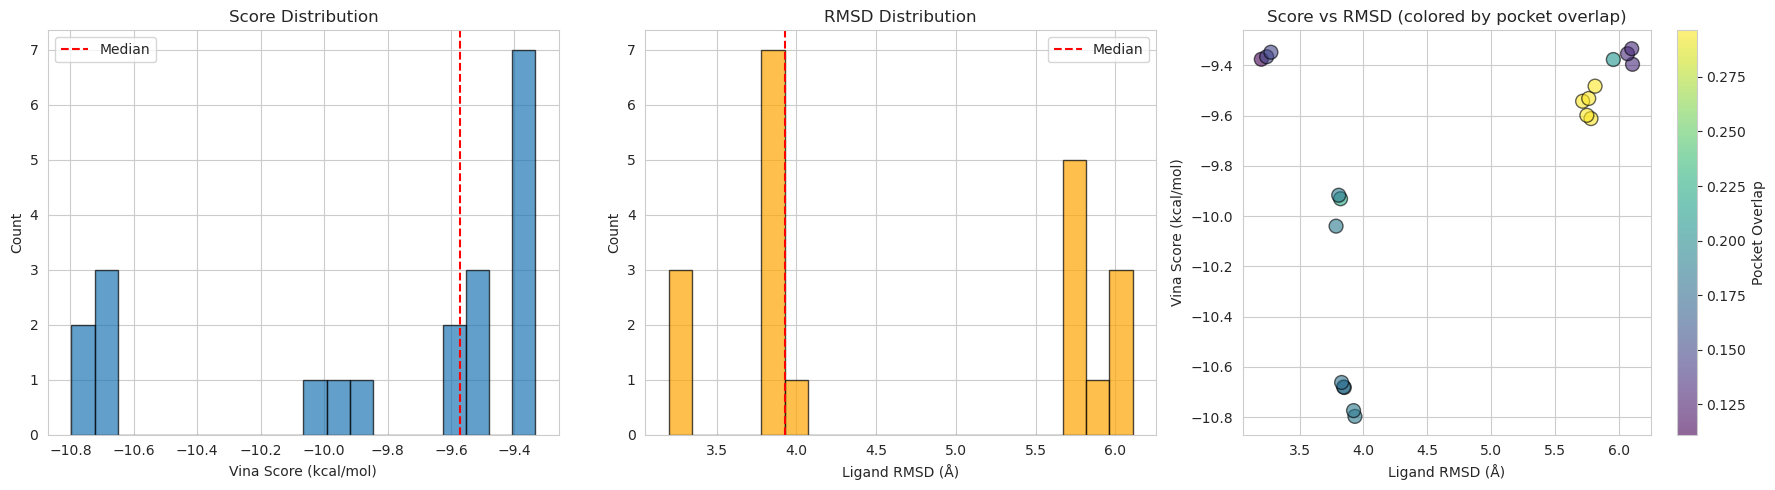

✓ Saved: score_rmsd_distribution.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score distribution
df['vina_score'] = pd.to_numeric(df['vina_score'], errors='coerce')
axes[0].hist(df['vina_score'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(df['vina_score'].median(), color='red', linestyle='--', label='Median')
axes[0].set_xlabel('Vina Score (kcal/mol)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

# RMSD distribution
axes[1].hist(df['ligand_rmsd'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(df['ligand_rmsd'].median(), color='red', linestyle='--', label='Median')
axes[1].set_xlabel('Ligand RMSD (Å)')
axes[1].set_ylabel('Count')
axes[1].set_title('RMSD Distribution')
axes[1].legend()

# Score vs RMSD
scatter = axes[2].scatter(df['ligand_rmsd'], df['vina_score'], 
                         c=df['pocket_overlap'], cmap='viridis', 
                         s=100, alpha=0.6, edgecolor='black')
axes[2].set_xlabel('Ligand RMSD (Å)')
axes[2].set_ylabel('Vina Score (kcal/mol)')
axes[2].set_title('Score vs RMSD (colored by pocket overlap)')
cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label('Pocket Overlap')

# Flag allosteric
# if df['possible_allosteric'].sum() > 0:
#     allosteric = df[df['possible_allosteric']]
#     axes[2].scatter(allosteric['ligand_rmsd'], allosteric['vina_score'],
#                    marker='x', s=200, c='red', label='Possible allosteric', linewidths=3)
#     axes[2].legend()

plt.tight_layout()
plt.savefig(dirs['filtered'] / 'score_rmsd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: score_rmsd_distribution.png")

## 1.3 ProLIF Interaction Fingerprints

In [6]:
def calculate_prolif_fingerprints(pose_pdb, receptor_pdb):
    """
    Calculate interaction fingerprints using ProLIF
    Returns: DataFrame with interaction counts
    """
    try:
        # Load structures
        prot_rdkit = Chem.MolFromPDBFile(str(receptor_pdb), removeHs=False)
        lig_rdkit = Chem.MolFromPDBFile(str(pose_pdb), removeHs=False)
        prot = plf.Molecule(prot_rdkit)
        lig = plf.Molecule(lig_rdkit)

        if (lig is None) or (prot is None):
            raise ValueError("Failed to load ligand or protein structure.")
        
        # Define interactions to detect
        fp = plf.Fingerprint(
            interactions=[
                'HBDonor', 'HBAcceptor', 'PiStacking', 'PiCation',
                'Hydrophobic', 'MetalAcceptor'
            ]
        )
        
        # Calculate fingerprint
        fp.run_from_iterable([lig], prot)
        
        # Convert to dataframe
        df_fp = fp.to_dataframe()

        # Count interactions
        interaction_counts = {}
        for col in df_fp.columns:
            interaction_type = col[1]  # (residue, interaction_type)
            if interaction_type not in interaction_counts:
                interaction_counts[interaction_type] = 0
            interaction_counts[interaction_type] += df_fp[col].sum()
        
        return interaction_counts, df_fp
    
    except Exception as e:
        print(f"Warning: ProLIF failed for {pose_pdb}: {e}")
        return {}, None

print("✓ ProLIF function defined")

✓ ProLIF function defined


In [ ]:
# Calculate fingerprints for all poses
receptor_pdb = dirs['prepared'] / 'receptor.pdb'

print("Calculating ProLIF fingerprints for all poses...")
print("This may take a few minutes...\n")

interaction_data = []

for idx, row in df.iterrows():
    pose_name = row['pose_name']
    pose_pdb = row['pdb_file']
    
    print(f"Processing {pose_name}...", end=' ')
    
    counts, df_fp = calculate_prolif_fingerprints(pose_pdb, receptor_pdb)

    if counts:
        counts['pose_name'] = pose_name
        interaction_data.append(counts)
        print("✓")
    else:
        print("✗")

# Create interaction dataframe
df_interactions = pd.DataFrame(interaction_data).fillna(0)
df_interactions.set_index('pose_name', inplace=True)

# Merge with main dataframe
df = df.merge(df_interactions, left_on='pose_name', right_index=True, how='left')

# Save updated dataframe
interaction_csv = dirs['filtered'] / 'poses_with_interactions.csv'
df.to_csv(interaction_csv, index=False)

print(f"\n✓ Saved interactions: {interaction_csv}")
print(f"\nInteraction summary:")
print(df_interactions.describe())

Calculating ProLIF fingerprints for all poses...
This may take a few minutes...

Processing seed3_pose1... 

100%|██████████| 1/1 [00:00<00:00, 72.09it/s]

{'LEU139.A': 1, 'ALA213.A': 1} ligand           UNL1.          
protein        LEU139.A ALA213.A
interaction Hydrophobic  HBDonor
Frame                           
0                  True     True
✓
Processing seed1_pose1... 


100%|██████████| 1/1 [00:00<00:00, 115.24it/s]

{'LEU139.A': 1, 'ALA213.A': 1} ligand           UNL1.          
protein        LEU139.A ALA213.A
interaction Hydrophobic  HBDonor
Frame                           
0                  True     True
✓
Processing seed4_pose1... 

...

{'ASN261.A': 1, 'LEU263.A': 1} ligand        UNL1.             
protein     ASN261.A    LEU263.A
interaction  HBDonor Hydrophobic
Frame                           
0               True        True
✓
Processing seed4_pose4... 


100%|██████████| 1/1 [00:00<00:00, 70.99it/s]

{'LEU139.A': 1, 'ALA213.A': 1} ligand           UNL1.          
protein        LEU139.A ALA213.A
interaction Hydrophobic  HBDonor
Frame                           
0                  True     True
✓
Processing seed3_pose4... 


100%|██████████| 1/1 [00:00<00:00, 57.97it/s]

{'ASN261.A': 1, 'LEU263.A': 1} ligand        UNL1.             
protein     ASN261.A    LEU263.A
interaction  HBDonor Hydrophobic
Frame                           
0               True        True
✓

✓ Saved interactions: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/runs/complex_0081_off01/filtered/poses_with_interactions.csv

Interaction summary:
        LEU139.A   ALA213.A   PRO214.A  VAL147.A   LEU263.A   ASN261.A
count  20.000000  20.000000  20.000000  20.00000  20.000000  20.000000
mean    0.550000   0.450000   0.050000   0.35000   0.200000   0.100000
std     0.510418   0.510418   0.223607   0.48936   0.410391   0.307794
min     0.000000   0.000000   0.000000   0.00000   0.000000   0.000000
25%     0.000000   0.000000   0.000000   0.00000   0.000000   0.000000
50%     1.000000   0.000000   0.000000   0.00000   0.000000   0.000000
75%     1.000000   1.000000   0.000000   1.00000   0.000000   0.000000
max     1.000000   1.000000   1.000000   1.00000   1.000000   1.000000


## 1.4 Interaction Heatmap

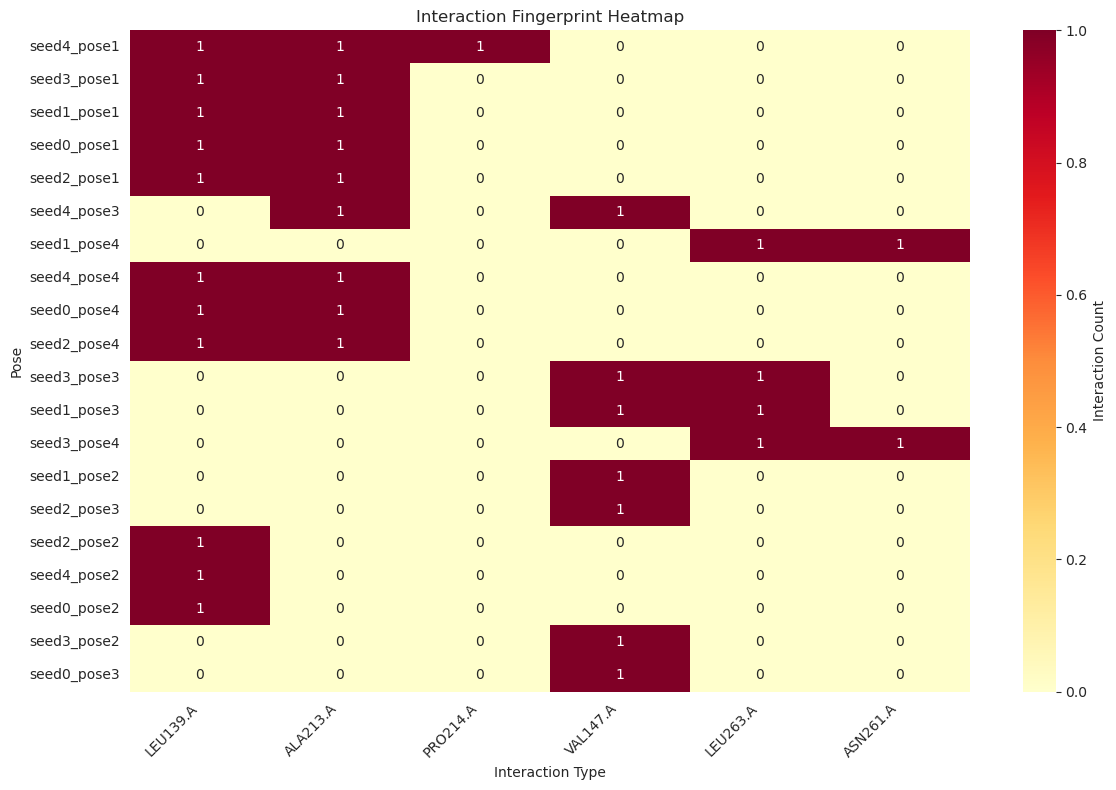

✓ Saved: interaction_heatmap.png


In [8]:
# Create interaction heatmap
interaction_cols = df_interactions.columns.tolist()

if len(interaction_cols) > 0:
    plt.figure(figsize=(12, 8))
    
    # Sort by total interactions
    df_interactions['total'] = df_interactions.sum(axis=1)
    df_sorted = df_interactions.sort_values('total', ascending=False).drop('total', axis=1)
    
    sns.heatmap(df_sorted, cmap='YlOrRd', annot=True, fmt='.0f', 
                cbar_kws={'label': 'Interaction Count'})
    plt.xlabel('Interaction Type')
    plt.ylabel('Pose')
    plt.title('Interaction Fingerprint Heatmap')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(dirs['filtered'] / 'interaction_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: interaction_heatmap.png")
else:
    print("No interactions detected")

## 1.5 Pose Selection for Relaxation

In [ ]:
# Calculate composite score for ranking
# Lower is better: combine vina score, RMSD, and interaction counts

# Normalize metrics to 0-1 scale
df['score_norm'] = (df['vina_score'] - df['vina_score'].min()) / (df['vina_score'].max() - df['vina_score'].min())
df['rmsd_norm'] = (df['ligand_rmsd'] - df['ligand_rmsd'].min()) / (df['ligand_rmsd'].max() - df['ligand_rmsd'].min())

# Count total interactions (higher is better, so invert)
if len(interaction_cols) > 0:
    df['total_interactions'] = df[interaction_cols].sum(axis=1)
    df['interactions_norm'] = 1 - (df['total_interactions'] - df['total_interactions'].min()) / (df['total_interactions'].max() - df['total_interactions'].min())
else:
    df['interactions_norm'] = 0.5

# Composite score (lower is better)
df['composite_score'] = (
    0.5 * df['score_norm'] +      # 50% weight on vina score
    0.2 * df['rmsd_norm'] +        # 20% weight on RMSD
    0.3 * df['interactions_norm']  # 30% weight on interactions (inverted)
)

# Sort by composite score
df_sorted = df.sort_values('composite_score')

print("Top 10 poses by composite score:")
print(df_sorted[[
    'pose_name', 'vina_score', 'ligand_rmsd', 'pocket_overlap',
    'total_interactions', 'composite_score', 'possible_allosteric'
]].head(10))

# Select top N for relaxation
# n_to_relax = min(config['filtering']['max_poses_to_relax'], len(df_sorted))
n_to_relax = 10
df_selected = df_sorted.head(n_to_relax)

print(f"\n✓ Selected {len(df_selected)} poses for FastRelax")

# Save selection
selected_csv = dirs['filtered'] / 'poses_selected_for_relax.csv'
df_selected.to_csv(selected_csv, index=False)
print(f"✓ Saved: {selected_csv}")

Top 10 poses by composite score:
      pose_name  vina_score  ligand_rmsd  pocket_overlap  total_interactions  \
2   seed4_pose1     -10.682     3.849762        0.178571                 3.0   
0   seed3_pose1     -10.797     3.933038        0.185185                 2.0   
1   seed1_pose1     -10.774     3.922332        0.185185                 2.0   
3   seed0_pose1     -10.680     3.844047        0.178571                 2.0   
4   seed2_pose1     -10.662     3.828794        0.178571                 2.0   
5   seed4_pose2     -10.040     3.785254        0.185185                 1.0   
6   seed0_pose2      -9.931     3.820117        0.222222                 1.0   
7   seed2_pose2      -9.917     3.805940        0.185185                 1.0   
15  seed2_pose4      -9.376     3.199527        0.111111                 2.0   
16  seed0_pose4      -9.366     3.241426        0.148148                 2.0   

    composite_score  possible_allosteric  
2          0.106380                 True  


## 1.6 Generate PyMOL Visualization Script

In [10]:
# Generate PyMOL script to visualize top poses
pymol_script = dirs['filtered'] / 'visualize_top_poses.pml'

receptor_pdb = dirs['prepared'] / 'receptor.pdb'
target_ligand_pdb = dirs['prepared'] / 'target_ligand.pdb'

with open(pymol_script, 'w') as f:
    f.write("# PyMOL visualization script for top docked poses\n\n")
    
    # Load receptor
    f.write(f"load {receptor_pdb}, receptor\n")
    f.write("hide everything, receptor\n")
    f.write("show cartoon, receptor\n")
    f.write("color gray80, receptor\n\n")
    
    # Load target ligand
    f.write(f"load {target_ligand_pdb}, target_ligand\n")
    f.write("show sticks, target_ligand\n")
    f.write("color green, target_ligand\n")
    f.write("set stick_radius, 0.15, target_ligand\n\n")
    
    # Load top 5 poses
    colors = ['cyan', 'magenta', 'yellow', 'orange', 'salmon']
    
    for i, (idx, row) in enumerate(df_selected.head(5).iterrows()):
        pose_name = row['pose_name']
        pose_pdb = row['pdb_file']
        color = colors[i % len(colors)]
        
        f.write(f"# Pose {i+1}: {pose_name} (score: {row['vina_score']:.2f})\n")
        f.write(f"load {pose_pdb}, {pose_name}\n")
        f.write(f"show sticks, {pose_name}\n")
        f.write(f"color {color}, {pose_name}\n")
        f.write(f"set stick_radius, 0.12, {pose_name}\n\n")
    
    # Center view
    f.write("# Center view on target ligand\n")
    f.write("center target_ligand\n")
    f.write("zoom target_ligand, 8\n\n")
    
    # Show pocket residues
    f.write("# Show pocket residues\n")
    f.write("select pocket, receptor within 5 of target_ligand\n")
    f.write("show sticks, pocket\n")
    f.write("color gray60, pocket\n\n")
    
    f.write("# Set background\n")
    f.write("bg_color white\n")
    f.write("set ray_shadows, 0\n")
    f.write("set antialias, 2\n")

print(f"✓ Generated PyMOL script: {pymol_script}")
print(f"\nTo visualize:")
print(f"  pymol {pymol_script}")

✓ Generated PyMOL script: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/runs/complex_0081_off01/filtered/visualize_top_poses.pml

To visualize:
  pymol /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/runs/complex_0081_off01/filtered/visualize_top_poses.pml


---
## End of Part 1

**Next steps:**
1. Review the selected poses
2. Run: `python fastrelax_prep.py config.yaml`
3. Submit FastRelax jobs to server
4. Continue with Part 2 below after relaxation completes

---
# PART 2: Post-FastRelax Analysis
Run this section after FastRelax completes

## 2.1 Load Relaxed Structures

In [11]:
# Load relaxed structures
prep_csv = dirs['relaxed'] / 'fastrelax_prepared.csv'
df_prep = pd.read_csv(prep_csv)
display(df_prep.head())

print(f"Loaded {len(df_prep)} prepared poses")

# Find relaxed PDB files
relaxed_data = []

for idx, row in df_prep.iterrows():
    pose_name = row['pose_name']
    relaxed_pdb = dirs['relaxed'] / f"{pose_name}_0001.pdb"
    score_file = dirs['relaxed'] / f"{pose_name}_score.sc"
    
    if relaxed_pdb.exists():
        relaxed_data.append({
            'pose_name': pose_name,
            'relaxed_pdb': str(relaxed_pdb),
            'input_pdb': row['complex_pdb'],
            'score_file': str(score_file) if score_file.exists() else None
        })

df_relaxed = pd.DataFrame(relaxed_data)
print(f"\nFound {len(df_relaxed)} relaxed structures")

if len(df_relaxed) == 0:
    print("\n⚠ No relaxed structures found!")
    print("Make sure FastRelax jobs have completed.")
else:
    df_relaxed.head()

,pose_name,seed,complex_pdb,params_file,flags_file,n_pocket_residues,pocket_residues
0,complex_0081_config03_seed0,0,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,22,"62,63,64,65,66,67,68,69,70,84,85,86,87,88,137,..."
1,complex_0081_config03_seed1,1,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,22,"62,63,64,65,66,67,68,69,70,84,85,86,87,88,137,..."
2,complex_0081_config03_seed2,2,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,22,"62,63,64,65,66,67,68,69,70,84,85,86,87,88,137,..."
3,complex_0081_config03_seed3,3,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,21,"62,63,64,65,66,67,68,69,84,85,86,87,88,137,138..."
4,complex_0081_config03_seed4,4,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,22,"62,63,64,65,66,67,68,69,70,84,85,86,87,88,137,..."


Loaded 5 prepared poses

Found 0 relaxed structures

⚠ No relaxed structures found!
Make sure FastRelax jobs have completed.


## 2.2 Parse Rosetta Scores

In [ ]:
def parse_rosetta_scorefile(score_file):
    """
    Parse Rosetta score file
    Returns: dict with scores
    """
    scores = {}
    
    with open(score_file, 'r') as f:
        lines = f.readlines()
        
        # Find header line (starts with SCORE:)
        header_idx = None
        for i, line in enumerate(lines):
            if line.startswith('SCORE:') and 'description' in line:
                header_idx = i
                break
        
        if header_idx is None:
            return scores
        
        # Parse header
        header = lines[header_idx].split()[1:]  # Skip 'SCORE:'
        
        # Parse data (next line)
        if header_idx + 1 < len(lines):
            data = lines[header_idx + 1].split()[1:]  # Skip 'SCORE:'
            
            for key, value in zip(header, data):
                try:
                    scores[key] = float(value)
                except ValueError:
                    scores[key] = value
    
    return scores

# Parse all score files
score_data = []

for idx, row in df_relaxed.iterrows():
    if row['score_file'] and Path(row['score_file']).exists():
        scores = parse_rosetta_scorefile(row['score_file'])
        scores['pose_name'] = row['pose_name']
        score_data.append(scores)

if score_data:
    df_scores = pd.DataFrame(score_data)
    df_relaxed = df_relaxed.merge(df_scores, on='pose_name', how='left')
    
    print(f"✓ Parsed {len(score_data)} score files")
    print(f"\nScore statistics:")
    print(df_scores[['total_score']].describe())
else:
    print("⚠ No score files found")

## 2.3 Calculate RMSD Drift (Before/After Relaxation)

In [ ]:
def calculate_ligand_rmsd_drift(input_pdb, relaxed_pdb, ligand_chain='X', ligand_resid=1):
    """
    Calculate RMSD between input and relaxed ligand
    """
    parser = PDBParser(QUIET=True)
    
    try:
        input_structure = parser.get_structure('input', input_pdb)
        relaxed_structure = parser.get_structure('relaxed', relaxed_pdb)
    except:
        return None
    
    # Get ligand atoms
    def get_ligand_atoms(structure, chain, resid):
        atoms = []
        for model in structure:
            for ch in model:
                if ch.id == chain:
                    for residue in ch:
                        if residue.id[1] == resid:
                            for atom in residue.get_atoms():
                                if atom.element != 'H':
                                    atoms.append(atom)
        return atoms
    
    input_atoms = get_ligand_atoms(input_structure, ligand_chain, ligand_resid)
    relaxed_atoms = get_ligand_atoms(relaxed_structure, ligand_chain, ligand_resid)
    
    if len(input_atoms) != len(relaxed_atoms) or len(input_atoms) == 0:
        return None
    
    # Calculate RMSD
    super_imposer = Superimposer()
    super_imposer.set_atoms(input_atoms, relaxed_atoms)
    rmsd = super_imposer.rms
    
    return rmsd

# Calculate RMSD drift for all poses
print("Calculating RMSD drift...")

rmsd_drifts = []
for idx, row in df_relaxed.iterrows():
    rmsd = calculate_ligand_rmsd_drift(row['input_pdb'], row['relaxed_pdb'])
    rmsd_drifts.append(rmsd)
    
df_relaxed['rmsd_drift'] = rmsd_drifts

print(f"\n✓ RMSD drift statistics:")
print(f"  Mean: {df_relaxed['rmsd_drift'].mean():.3f} Å")
print(f"  Median: {df_relaxed['rmsd_drift'].median():.3f} Å")
print(f"  Max: {df_relaxed['rmsd_drift'].max():.3f} Å")

# Flag large drifts
drift_cutoff = config['qc']['rmsd_drift_cutoff']
n_large_drift = (df_relaxed['rmsd_drift'] > drift_cutoff).sum()
print(f"\n⚠ {n_large_drift} poses with RMSD drift > {drift_cutoff} Å")

## 2.4 PyRosetta: H-bonds and Hydrophobic Contacts

In [ ]:
if PYROSETTA_AVAILABLE:
    # Initialize PyRosetta
    pyrosetta.init('-mute all')
    
    def calculate_hbonds_to_ligand(pose, ligand_res_num):
        """
        Calculate H-bonds between ligand and protein
        """
        hbond_set = rosetta.core.scoring.hbonds.HBondSet()
        pose.update_residue_neighbors()
        rosetta.core.scoring.hbonds.fill_hbond_set(pose, False, hbond_set)
        
        hbonds = []
        for hb in hbond_set.hbonds():
            don_res = hb.don_res()
            acc_res = hb.acc_res()
            
            if don_res == ligand_res_num or acc_res == ligand_res_num:
                hbonds.append({
                    'donor_res': don_res,
                    'acceptor_res': acc_res,
                    'energy': hb.energy()
                })
        
        return hbonds
    
    def calculate_hydrophobic_contacts(pose, ligand_res_num, cutoff=4.5):
        """
        Count hydrophobic contacts between ligand and protein
        """
        lig_res = pose.residue(ligand_res_num)
        hydrophobic_atoms = {'C', 'S'}
        
        contacts = 0
        
        for i in range(1, pose.total_residue() + 1):
            if i == ligand_res_num:
                continue
            
            prot_res = pose.residue(i)
            if not prot_res.is_protein():
                continue
            
            for lig_atom in range(1, lig_res.natoms() + 1):
                if lig_res.atom_type(lig_atom).element() not in hydrophobic_atoms:
                    continue
                
                for prot_atom in range(1, prot_res.natoms() + 1):
                    if prot_res.atom_type(prot_atom).element() not in hydrophobic_atoms:
                        continue
                    
                    dist = lig_res.xyz(lig_atom).distance(prot_res.xyz(prot_atom))
                    if dist <= cutoff:
                        contacts += 1
        
        return contacts
    
    # Calculate for all relaxed poses
    print("Calculating H-bonds and hydrophobic contacts...\n")
    
    qc_data = []
    
    for idx, row in df_relaxed.iterrows():
        pose_name = row['pose_name']
        print(f"Processing {pose_name}...", end=' ')
        
        try:
            # Load pose
            pose = pyrosetta.pose_from_pdb(row['relaxed_pdb'])
            
            # Find ligand residue (last residue, chain X)
            ligand_res_num = pose.total_residue()
            
            # Calculate H-bonds
            hbonds = calculate_hbonds_to_ligand(pose, ligand_res_num)
            n_hbonds = len(hbonds)
            hbond_energy = sum([hb['energy'] for hb in hbonds])
            
            # Calculate hydrophobic contacts
            n_hydrophobic = calculate_hydrophobic_contacts(pose, ligand_res_num)
            
            qc_data.append({
                'pose_name': pose_name,
                'n_hbonds': n_hbonds,
                'hbond_energy': hbond_energy,
                'n_hydrophobic': n_hydrophobic
            })
            
            print(f"✓ (H-bonds: {n_hbonds}, Hydrophobic: {n_hydrophobic})")
        
        except Exception as e:
            print(f"✗ Error: {e}")
            qc_data.append({
                'pose_name': pose_name,
                'n_hbonds': 0,
                'hbond_energy': 0,
                'n_hydrophobic': 0
            })
    
    # Merge with dataframe
    df_qc = pd.DataFrame(qc_data)
    df_relaxed = df_relaxed.merge(df_qc, on='pose_name', how='left')
    
    print(f"\n✓ QC calculations complete")
    print(f"\nH-bond statistics:")
    print(df_qc[['n_hbonds']].describe())
    print(f"\nHydrophobic contact statistics:")
    print(df_qc[['n_hydrophobic']].describe())

else:
    print("⚠ PyRosetta not available, skipping H-bond and contact calculations")
    df_relaxed['n_hbonds'] = 0
    df_relaxed['n_hydrophobic'] = 0

## 2.5 Final Filtering and Scoring

In [ ]:
# Apply QC filters
print("Applying final QC filters...\n")
print(f"Starting with {len(df_relaxed)} poses")

df_final = df_relaxed.copy()

# Filter 1: RMSD drift
drift_cutoff = config['qc']['rmsd_drift_cutoff']
df_final = df_final[df_final['rmsd_drift'] <= drift_cutoff]
print(f"After RMSD drift filter (<= {drift_cutoff} Å): {len(df_final)}")

# Filter 2: Minimum H-bonds (if available)
if PYROSETTA_AVAILABLE:
    min_hbonds = config['qc']['min_hbonds']
    df_final = df_final[df_final['n_hbonds'] >= min_hbonds]
    print(f"After H-bond filter (>= {min_hbonds}): {len(df_final)}")
    
    # Filter 3: Minimum hydrophobic contacts
    min_contacts = config['qc']['min_hydrophobic']
    df_final = df_final[df_final['n_hydrophobic'] >= min_contacts]
    print(f"After hydrophobic filter (>= {min_contacts}): {len(df_final)}")

# Filter 4: Energy filtering (if scores available)
if 'total_score' in df_final.columns:
    # Take bottom 25% by energy, or top N
    energy_cutoff = df_final['total_score'].quantile(config['qc']['energy_percentile'])
    df_final = df_final[df_final['total_score'] <= energy_cutoff]
    print(f"After energy filter (<= {energy_cutoff:.1f}): {len(df_final)}")

# Limit to top N
top_n = config['qc']['top_n_final']
if len(df_final) > top_n:
    if 'total_score' in df_final.columns:
        df_final = df_final.nsmallest(top_n, 'total_score')
    else:
        df_final = df_final.head(top_n)
    print(f"Limited to top {top_n}: {len(df_final)}")

print(f"\n✓ Final selection: {len(df_final)} poses")

## 2.6 Final Scoring and Ranking

In [ ]:
# Calculate final composite score
if len(df_final) > 0 and 'total_score' in df_final.columns:
    # Normalize metrics
    df_final['energy_norm'] = (df_final['total_score'] - df_final['total_score'].min()) / (df_final['total_score'].max() - df_final['total_score'].min() + 1e-6)
    df_final['drift_norm'] = (df_final['rmsd_drift'] - df_final['rmsd_drift'].min()) / (df_final['rmsd_drift'].max() - df_final['rmsd_drift'].min() + 1e-6)
    
    if PYROSETTA_AVAILABLE:
        # Higher H-bonds and contacts are better (invert for scoring)
        df_final['hbond_norm'] = 1 - (df_final['n_hbonds'] - df_final['n_hbonds'].min()) / (df_final['n_hbonds'].max() - df_final['n_hbonds'].min() + 1e-6)
        df_final['contact_norm'] = 1 - (df_final['n_hydrophobic'] - df_final['n_hydrophobic'].min()) / (df_final['n_hydrophobic'].max() - df_final['n_hydrophobic'].min() + 1e-6)
        
        # Final score (lower is better)
        df_final['final_score'] = (
            0.4 * df_final['energy_norm'] +
            0.2 * df_final['drift_norm'] +
            0.2 * df_final['hbond_norm'] +
            0.2 * df_final['contact_norm']
        )
    else:
        df_final['final_score'] = (
            0.6 * df_final['energy_norm'] +
            0.4 * df_final['drift_norm']
        )
    
    # Sort by final score
    df_final = df_final.sort_values('final_score')
    
    print("Final ranked poses:")
    display_cols = ['pose_name', 'total_score', 'rmsd_drift', 'n_hbonds', 'n_hydrophobic', 'final_score']
    display_cols = [col for col in display_cols if col in df_final.columns]
    print(df_final[display_cols])
else:
    print("No poses passed all filters or scores not available")

## 2.7 Save Final Results

In [ ]:
# Save final CSV
final_csv = dirs['final'] / 'final_poses.csv'
df_final.to_csv(final_csv, index=False)
print(f"✓ Saved final results: {final_csv}")

# Copy final PDB files
import shutil

for idx, row in df_final.iterrows():
    src = row['relaxed_pdb']
    dst = dirs['final'] / f"{row['pose_name']}_final.pdb"
    shutil.copy(src, dst)

print(f"✓ Copied {len(df_final)} final PDB files to {dirs['final']}")

## 2.8 Final Visualization

In [ ]:
if len(df_final) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Energy distribution
    if 'total_score' in df_final.columns:
        axes[0, 0].bar(range(len(df_final)), df_final['total_score'])
        axes[0, 0].set_xlabel('Pose Rank')
        axes[0, 0].set_ylabel('Total Score (REU)')
        axes[0, 0].set_title('Rosetta Energy')
    
    # RMSD drift
    axes[0, 1].bar(range(len(df_final)), df_final['rmsd_drift'], color='orange')
    axes[0, 1].axhline(drift_cutoff, color='red', linestyle='--', label=f'Cutoff: {drift_cutoff} Å')
    axes[0, 1].set_xlabel('Pose Rank')
    axes[0, 1].set_ylabel('RMSD Drift (Å)')
    axes[0, 1].set_title('Ligand RMSD Drift')
    axes[0, 1].legend()
    
    # H-bonds
    if PYROSETTA_AVAILABLE:
        axes[1, 0].bar(range(len(df_final)), df_final['n_hbonds'], color='green')
        axes[1, 0].set_xlabel('Pose Rank')
        axes[1, 0].set_ylabel('Number of H-bonds')
        axes[1, 0].set_title('H-bonds to Ligand')
        
        # Hydrophobic contacts
        axes[1, 1].bar(range(len(df_final)), df_final['n_hydrophobic'], color='purple')
        axes[1, 1].set_xlabel('Pose Rank')
        axes[1, 1].set_ylabel('Number of Contacts')
        axes[1, 1].set_title('Hydrophobic Contacts')
    
    plt.tight_layout()
    plt.savefig(dirs['final'] / 'final_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: final_analysis.png")
else:
    print("No poses to visualize")

## 2.9 Generate Final PyMOL Script

In [ ]:
# Generate PyMOL script for final poses
pymol_script = dirs['final'] / 'visualize_final_poses.pml'

with open(pymol_script, 'w') as f:
    f.write("# PyMOL visualization script for final relaxed poses\n\n")
    
    # Load receptor
    receptor_pdb = dirs['prepared'] / 'receptor.pdb'
    f.write(f"load {receptor_pdb}, receptor\n")
    f.write("hide everything, receptor\n")
    f.write("show cartoon, receptor\n")
    f.write("color gray80, receptor\n\n")
    
    # Load target ligand
    target_ligand_pdb = dirs['prepared'] / 'target_ligand.pdb'
    f.write(f"load {target_ligand_pdb}, target_ligand\n")
    f.write("show sticks, target_ligand\n")
    f.write("color green, target_ligand\n")
    f.write("set stick_radius, 0.15, target_ligand\n\n")
    
    # Load final poses
    colors = ['cyan', 'magenta', 'yellow', 'orange', 'salmon', 'lightblue', 'pink']
    
    for i, (idx, row) in enumerate(df_final.head(5).iterrows()):
        pose_name = row['pose_name']
        pose_pdb = dirs['final'] / f"{pose_name}_final.pdb"
        color = colors[i % len(colors)]
        
        score = row.get('total_score', 0)
        hbonds = row.get('n_hbonds', 0)
        
        f.write(f"# Rank {i+1}: {pose_name} (score: {score:.1f}, H-bonds: {hbonds})\n")
        f.write(f"load {pose_pdb}, {pose_name}\n")
        f.write(f"select {pose_name}_lig, {pose_name} and chain X\n")
        f.write(f"show sticks, {pose_name}_lig\n")
        f.write(f"color {color}, {pose_name}_lig\n")
        f.write(f"set stick_radius, 0.12, {pose_name}_lig\n")
        f.write(f"hide everything, {pose_name} and not chain X\n\n")
    
    # Pocket
    f.write("# Show pocket\n")
    f.write("select pocket, receptor within 5 of target_ligand\n")
    f.write("show sticks, pocket\n")
    f.write("color gray60, pocket\n\n")
    
    # View
    f.write("center target_ligand\n")
    f.write("zoom target_ligand, 8\n")
    f.write("bg_color white\n")

print(f"✓ Generated PyMOL script: {pymol_script}")
print(f"\nTo visualize final poses:")
print(f"  pymol {pymol_script}")

---
## Summary

In [ ]:
print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)

print(f"\nFinal Results:")
print(f"  Total docked poses: {len(df) if 'df' in locals() else 'N/A'}")
print(f"  Poses after filtering: {len(df_selected) if 'df_selected' in locals() else 'N/A'}")
print(f"  Poses after relaxation: {len(df_relaxed) if 'df_relaxed' in locals() else 'N/A'}")
print(f"  Final selected poses: {len(df_final) if 'df_final' in locals() else 'N/A'}")

print(f"\nOutput files:")
print(f"  - {dirs['final']}/final_poses.csv")
print(f"  - {dirs['final']}/final_analysis.png")
print(f"  - {dirs['final']}/visualize_final_poses.pml")
print(f"  - {len(df_final) if 'df_final' in locals() else 0} final PDB files")

if 'df_final' in locals() and len(df_final) > 0:
    print(f"\nTop 3 poses:")
    for i, (idx, row) in enumerate(df_final.head(3).iterrows(), 1):
        print(f"  {i}. {row['pose_name']}")
        if 'total_score' in row:
            print(f"     Energy: {row['total_score']:.1f} REU")
        print(f"     RMSD drift: {row['rmsd_drift']:.2f} Å")
        if PYROSETTA_AVAILABLE:
            print(f"     H-bonds: {row['n_hbonds']}, Hydrophobic: {row['n_hydrophobic']}")